# 01 · The free 100-ETF universe

**Block 2-3 of the workshop agenda** ("From Market Idea to Alpha Factor" /
"The Modern Quant Stack") - everything downstream in this workshop runs on
this dataset, so we start by loading it and confirming what it actually
contains before trusting anything built on top of it.

The data ships with this repo (`data/etf_universe.parquet`) so the session
doesn't depend on live internet access. It's the same free, Yahoo-Finance
-sourced universe used in the ETF case study in *Machine Learning for
Trading, 3rd Edition* - 100 liquid ETFs, selected backward-looking on a
$10M average-daily-volume threshold (see `data/README.md` for the point
-in-time eligibility file and its caveats).

In [1]:
import os
import subprocess
import sys
from pathlib import Path

if "COLAB_RELEASE_TAG" in os.environ:
    repo_dir = Path(os.environ.get("PACKT_WORKSHOP_DIR", "/content/packt-workshop"))
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/ml4t/packt-workshop.git",
                repo_dir,
            ],
            check=True,
        )
    ready = repo_dir.parent / ".packt-workshop-ready"
    if not ready.exists():
        # Colab's kernel already has numpy imported before this cell runs. Installing a
        # different numpy from requirements-colab.txt overwrites the files on disk but not
        # the compiled submodules already cached in this process, so importing a numpy
        # submodule for the first time later (e.g. via ml4t.engineer) mixes the new files
        # with the stale cached extension and raises ImportError. Put numpy back to the
        # version this process already has loaded once the rest of the install is done.
        import numpy as _colab_numpy

        colab_numpy_version = _colab_numpy.__version__
        subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "-r",
                repo_dir / "requirements-colab.txt",
            ],
            check=True,
        )
        subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "--force-reinstall",
                "--no-deps",
                f"numpy=={colab_numpy_version}",
            ],
            check=True,
        )
        ready.touch()
    os.chdir(repo_dir / "notebooks")

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

DATA_DIR = "../data"

prices = pd.read_parquet(f"{DATA_DIR}/etf_universe.parquet")
prices["timestamp"] = pd.to_datetime(prices["timestamp"])
prices = prices.sort_values(["symbol", "timestamp"]).reset_index(drop=True)
prices.head()

,timestamp,open,high,low,close,volume,symbol
0,2008-03-28,35.668968,35.668968,35.668968,35.668968,200.0,ACWI
1,2008-03-31,35.597774,35.597774,35.113644,35.113644,400.0,ACWI
2,2008-04-01,35.775767,36.060551,35.711691,36.060551,600.0,ACWI
3,2008-04-02,36.395160,36.594509,36.345323,36.459236,10700.0,ACWI
4,2008-04-03,42.503738,42.503738,36.274128,36.665703,29100.0,ACWI


## Sanity checks before we build anything

A workflow starts by interrogating the data, not by trusting the file
name. Three questions: how many names, what date range, how complete.

In [3]:
print(f"{prices['symbol'].nunique()} symbols")
print(f"{prices['timestamp'].min().date()} -> {prices['timestamp'].max().date()}")

coverage = prices.groupby("symbol")["timestamp"].agg(["min", "max", "count"])
coverage["years"] = ((coverage["max"] - coverage["min"]).dt.days / 365.25).round(1)
coverage.sort_values("min").head(10)

100 symbols
2006-01-03 -> 2025-12-31


,min,max,count,years
symbol,,,,
IYR,2006-01-03,2025-12-31,5031,20.0
SHY,2006-01-03,2025-12-31,5031,20.0
GLD,2006-01-03,2025-12-31,5031,20.0
XLB,2006-01-03,2025-12-31,5031,20.0
VWO,2006-01-03,2025-12-31,5031,20.0
IAU,2006-01-03,2025-12-31,5031,20.0
IBB,2006-01-03,2025-12-31,5031,20.0
IEF,2006-01-03,2025-12-31,5031,20.0
VUG,2006-01-03,2025-12-31,5031,20.0


Coverage is **not uniform** - some ETFs (SPY, QQQ) have traded since the
1990s/2000s; others launched much later (XLC in 2018, sector-momentum
funds like MTUM/VLUE in 2013). `coverage["min"]` shows this directly.
This matters the moment you rank across the full universe on any given
date: an equal-weight backtest starting in 2006 trades a very different,
much smaller universe than one starting in 2020.

In [4]:
short_history = coverage[coverage["years"] < 10].sort_values("years")
print(f"{len(short_history)} of {len(coverage)} ETFs have under 10 years of history")
short_history.head(10)

1 of 100 ETFs have under 10 years of history


,min,max,count,years
symbol,,,,
XLC,2018-06-19,2025-12-31,1895,7.5


## Point-in-time eligibility

`data/eligibility.csv` records, for each (symbol, year), whether that ETF
passed the $10M-ADV eligibility bar *as of that year* - this is what a
point-in-time backtest must filter on, not "is this symbol in the file at
all." The full 100-symbol universe was selected **backward-looking**, so
using all 100 from day one of any backtest is itself a survivorship-bias
bug - the same bug documented for the book's own US-equities case study
(Ch2 errata). Treat `eligibility.csv` as required reading before wiring
any of this into a backtest, not an optional file.

In [5]:
eligibility = pd.read_csv(f"{DATA_DIR}/eligibility.csv")
eligible_per_year = eligibility.groupby("eligible_year")["symbol"].nunique()
eligible_per_year

eligible_year
2007    43
2008    53
2009    67
2010    67
2011    75
2012    78
2013    78
2014    84
2015    89
2016    88
2017    94
2018    96
2019    96
2020    95
2021    95
2022    95
2023    96
2024    93
2025    93
2026    95
Name: symbol, dtype: int64

## Eligibility is not monotonic

A table of eligible-per-year counts hides which specific symbols come and
go. Plot the (symbol, year) grid directly, ordered by each ETF's
first-traded date - the same order as the coverage table above.

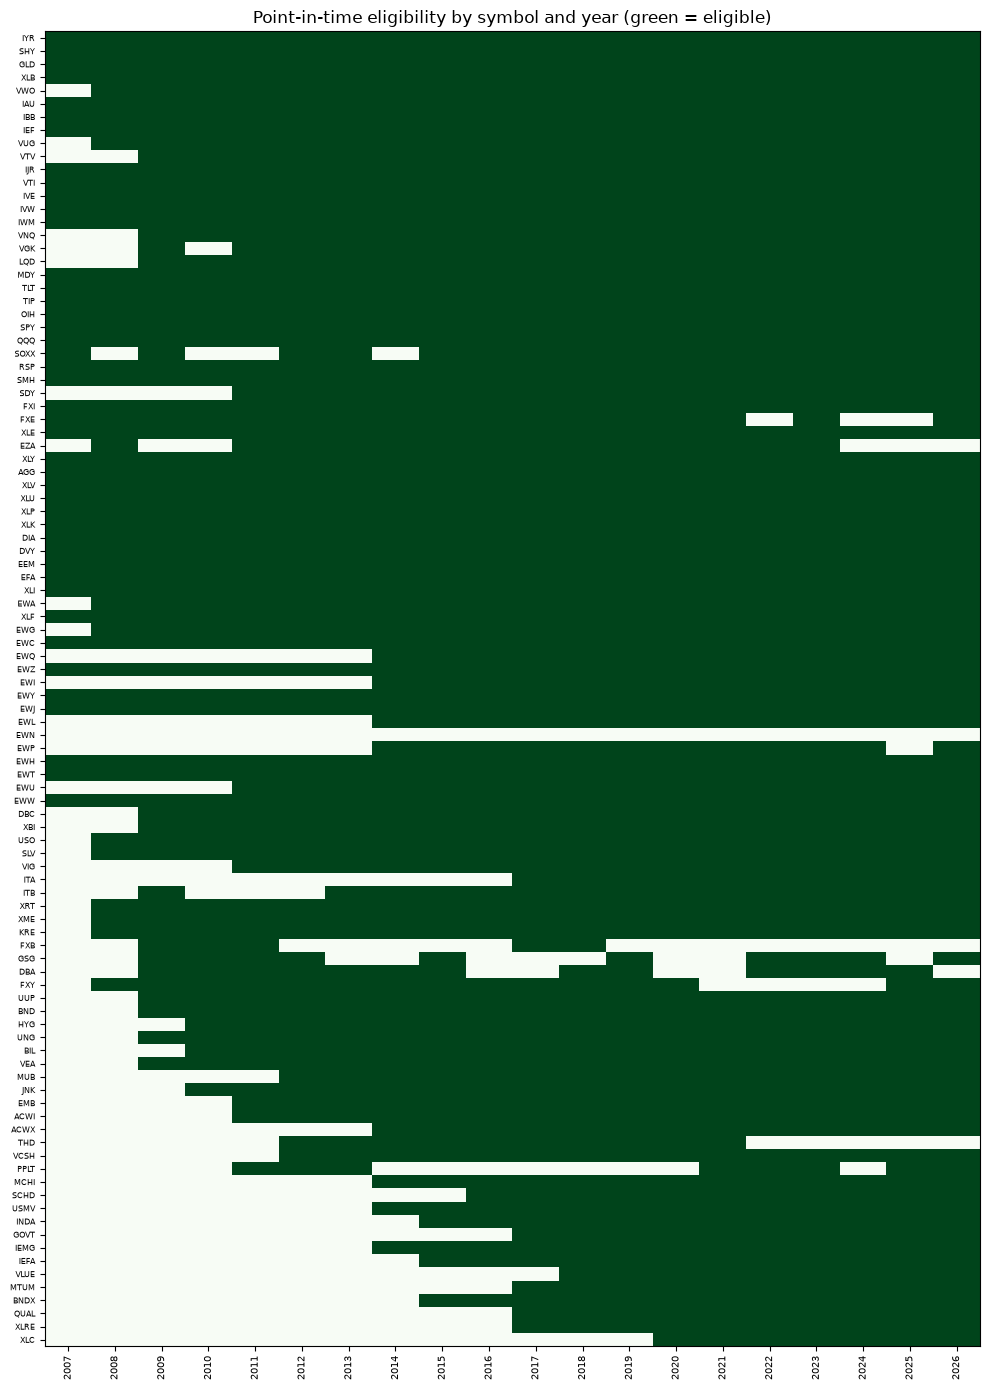

In [6]:
elig_matrix = (
    eligibility.assign(eligible=True)
    .pivot(index="symbol", columns="eligible_year", values="eligible")
    .reindex(coverage.sort_values("min").index)
    .fillna(False)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(10, 14))
ax.imshow(elig_matrix.values, aspect="auto", cmap="Greens", interpolation="nearest")
ax.set_xticks(range(len(elig_matrix.columns)))
ax.set_xticklabels(elig_matrix.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(elig_matrix.index)))
ax.set_yticklabels(elig_matrix.index, fontsize=6)
ax.set_title("Point-in-time eligibility by symbol and year (green = eligible)")
plt.tight_layout()
plt.show()

Two patterns, not one. Most of the grid's left edge is the phase-in
already described above: a symbol joins the file and stays eligible.
But **11 of 100 ETFs lose eligibility and later regain it** - GSG drops
out after 2012, briefly requalifies in 2015 and 2019, then holds
eligibility again from 2022. A backtest that treats eligibility as a
one-time filter, applied once at the start, will keep trading names the
universe itself dropped.

## What did these ETFs actually do?

Before building momentum, volatility, and mean-reversion features, look
at the return distribution those features are computed from - across
the whole universe, at three horizons.

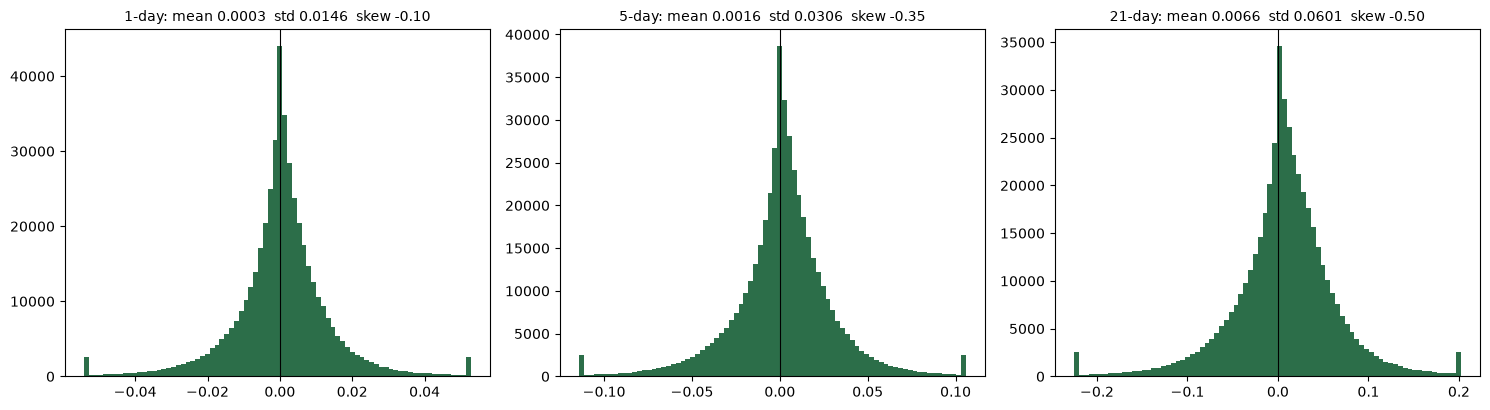

In [7]:
horizons = {1: "1-day", 5: "5-day", 21: "21-day"}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (h, label) in zip(axes, horizons.items()):
    r = prices.groupby("symbol")["close"].pct_change(h).dropna()
    lo, hi = r.quantile(0.005), r.quantile(0.995)
    ax.hist(r.clip(lo, hi), bins=80, color="#2c6e49")
    ax.set_title(
        f"{label}: mean {r.mean():.4f}  std {r.std():.4f}  skew {r.skew():.2f}", fontsize=10
    )
    ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

Clipped at the 0.5th/99.5th percentile so the tails don't compress the
rest of the histogram - the edge bars are that clipped mass, not a data
error. All three horizons are left-skewed with heavier-than-normal
tails (1-day kurtosis exceeds 15), the standard signature of daily
equity-like returns: mean and dispersion both grow with the horizon,
but not in proportion, and the downside tail is consistently longer
than the upside. This is why the feature set two notebooks from now
uses more than one lookback window - a single horizon would average
away exactly this shape.

## The universe is not 100 independent bets

Correlation across the file's 11 sector SPDRs, on daily returns.

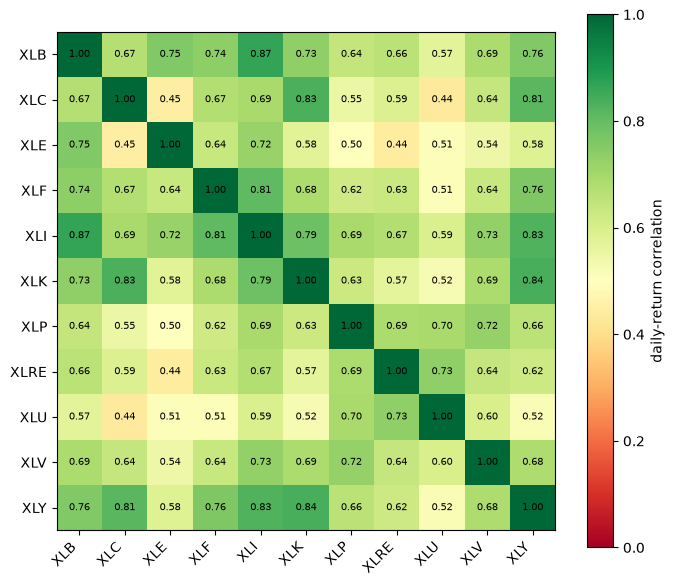

In [8]:
sector_etfs = ["XLB", "XLC", "XLE", "XLF", "XLI", "XLK", "XLP", "XLRE", "XLU", "XLV", "XLY"]
sector_wide = prices[prices["symbol"].isin(sector_etfs)].pivot(
    index="timestamp", columns="symbol", values="close"
)
sector_corr = sector_wide.pct_change().corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sector_corr.values, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(sector_corr.columns)))
ax.set_xticklabels(sector_corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(sector_corr.index)))
ax.set_yticklabels(sector_corr.index)
for i in range(len(sector_corr)):
    for j in range(len(sector_corr)):
        ax.text(j, i, f"{sector_corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, ax=ax, label="daily-return correlation")
plt.tight_layout()
plt.show()

Every pair is positive - these are still eleven equity sectors, not
independent assets - but the range runs from XLI/XLB at 0.87 down to
XLU/XLC at 0.44. XLC (Communication Services, launched 2018) is the
outlier to read carefully: its correlations are computed on roughly
1,900 overlapping trading days against the other sectors' 5,000+, so
they're the least statistically reliable numbers on this grid - the
same short-history caveat from the coverage table above, now showing up
as an estimation problem instead of a missing-row problem.

## From pandas to polars

`ml4t-backtest` is polars-first. We keep pandas for exploration (it's
what most of the room already knows) and convert once, right before it
touches the engine - that boundary is worth being deliberate about rather
than mixing the two libraries ad hoc through the pipeline.

In [9]:
prices_pl = pl.from_pandas(prices)
prices_pl.head()

timestamp,open,high,low,close,volume,symbol
datetime[μs],f64,f64,f64,f64,f64,str
2008-03-28 00:00:00,35.668968,35.668968,35.668968,35.668968,200.0,"""ACWI"""
2008-03-31 00:00:00,35.597774,35.597774,35.113644,35.113644,400.0,"""ACWI"""
2008-04-01 00:00:00,35.775767,36.060551,35.711691,36.060551,600.0,"""ACWI"""
2008-04-02 00:00:00,36.39516,36.594509,36.345323,36.459236,10700.0,"""ACWI"""
2008-04-03 00:00:00,42.503738,42.503738,36.274128,36.665703,29100.0,"""ACWI"""


**Next:** `02_features_labels.ipynb` - turn this raw OHLCV panel into
momentum/volatility/RSI features and forward-return labels.